## 1. Install paket

In [1]:
%pip install torch torchvision timm scikit-learn grad-cam seaborn opencv-python tqdm -q

Note: you may need to restart the kernel to use updated packages.


## 2. Imports & Config

In [2]:
import os, random
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm

# Configurasi hyperparameter dan device
SEED = 42
DATA_DIR = "dataset-soto-v2"
NUM_CLASSES = 6
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device: {DEVICE}")


C:\Users\degap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 3. Transforms

In [3]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## 4. Dataset Info

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"))
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"))

full_dataset = train_dataset

print(f"Train: {len(train_dataset):>6} images")
print(f"Val: {len(val_dataset):>6} images")
print(f"Test: {len(test_dataset):>6} images")
print(f"\nKelas: {train_dataset.classes}")
print(f"\nPer-class breakdown:")

for i, cls in enumerate(train_dataset.classes):
    tr = sum(1 for _, l in train_dataset.imgs if l == i)
    v  = sum(1 for _, l in val_dataset.imgs   if l == i)
    te = sum(1 for _, l in test_dataset.imgs  if l == i)
    print(f" {cls:<25} train={tr:>4} val={v:>3} test={te:>3}")


Train:   3246 images
Val:    693 images
Test:    693 images

Kelas: ['coto_makassar', 'soto_bandung', 'soto_betawi', 'soto_lamongan', 'soto_medan', 'soto_padang']

Per-class breakdown:
 coto_makassar             train= 491 val=105 test=105
 soto_bandung              train= 445 val= 95 test= 95
 soto_betawi               train= 677 val=144 test=144
 soto_lamongan             train= 748 val=160 test=160
 soto_medan                train= 352 val= 75 test= 75
 soto_padang               train= 533 val=114 test=114


## 5. Load Data

In [5]:
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tf)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Train batches : 102
Val batches : 22
Test batches : 22


## 6. Model DeiT Base

In [6]:
model = create_model("deit_base_patch16_224", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params : 85,803,270
Trainable params: 85,803,270


## 7. Loss, Optimizer & Scheduler

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## 8. Training

In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            
            if train: 
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc); history["val_acc"].append(vl_acc)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    print(f"Epoch: {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2%} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2%} | Time: {int(epoch_mins)}m {int(epoch_secs):02d}s")

torch.save(model.state_dict(), "Model/Deit_base.pth")

Epoch: 1/20 | Train Loss: 1.1006 | Train Acc: 65.77% | Val Loss: 0.7820 | Val Acc: 82.68% | Time: 1m 10s
Epoch: 2/20 | Train Loss: 0.7430 | Train Acc: 85.18% | Val Loss: 0.7296 | Val Acc: 86.87% | Time: 1m 09s
Epoch: 3/20 | Train Loss: 0.6519 | Train Acc: 89.43% | Val Loss: 0.7776 | Val Acc: 85.71% | Time: 1m 09s
Epoch: 4/20 | Train Loss: 0.5944 | Train Acc: 92.33% | Val Loss: 0.7075 | Val Acc: 87.30% | Time: 1m 09s
Epoch: 5/20 | Train Loss: 0.5520 | Train Acc: 93.99% | Val Loss: 0.7548 | Val Acc: 85.86% | Time: 1m 10s
Epoch: 6/20 | Train Loss: 0.5341 | Train Acc: 94.95% | Val Loss: 0.7490 | Val Acc: 84.27% | Time: 1m 11s
Epoch: 7/20 | Train Loss: 0.5120 | Train Acc: 95.93% | Val Loss: 0.6953 | Val Acc: 89.03% | Time: 1m 11s
Epoch: 8/20 | Train Loss: 0.4916 | Train Acc: 97.07% | Val Loss: 0.7249 | Val Acc: 86.87% | Time: 1m 11s
Epoch: 9/20 | Train Loss: 0.4693 | Train Acc: 97.91% | Val Loss: 0.6960 | Val Acc: 88.60% | Time: 1m 10s
Epoch: 10/20 | Train Loss: 0.4707 | Train Acc: 97.94% |

## 9. Training Curve

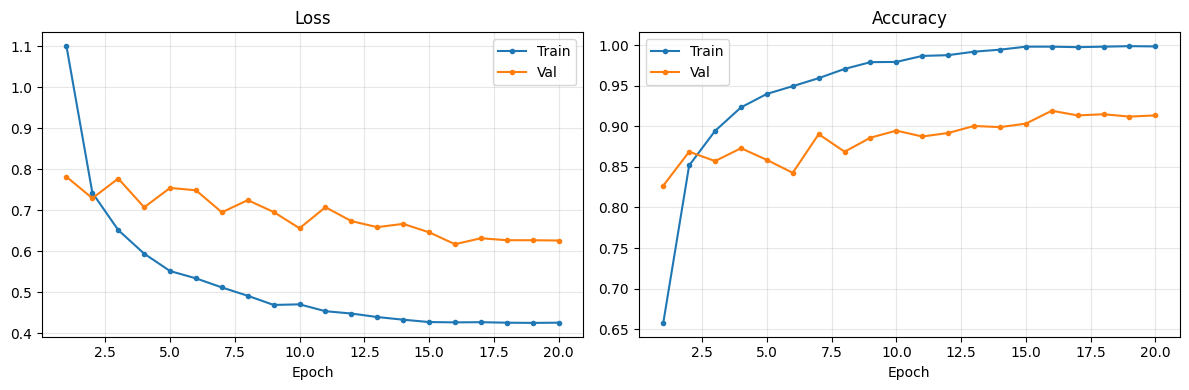

In [9]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train", marker="o", ms=3)
ax1.plot(epochs_range, history["val_loss"], label="Val", marker="o", ms=3)
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train", marker="o", ms=3)
ax2.plot(epochs_range, history["val_acc"], label="Val", marker="o", ms=3)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Dokumentasi/training_curve(Deit_Base).png", dpi=120)
plt.show()

## 10. Evaluation test set

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

               precision    recall  f1-score   support

coto_makassar       0.92      0.95      0.93       105
 soto_bandung       0.97      0.91      0.93        95
  soto_betawi       0.90      0.95      0.93       144
soto_lamongan       0.89      0.96      0.92       160
   soto_medan       0.92      0.75      0.82        75
  soto_padang       0.93      0.89      0.91       114

     accuracy                           0.91       693
    macro avg       0.92      0.90      0.91       693
 weighted avg       0.92      0.91      0.91       693



## 11. Confusion Matrix

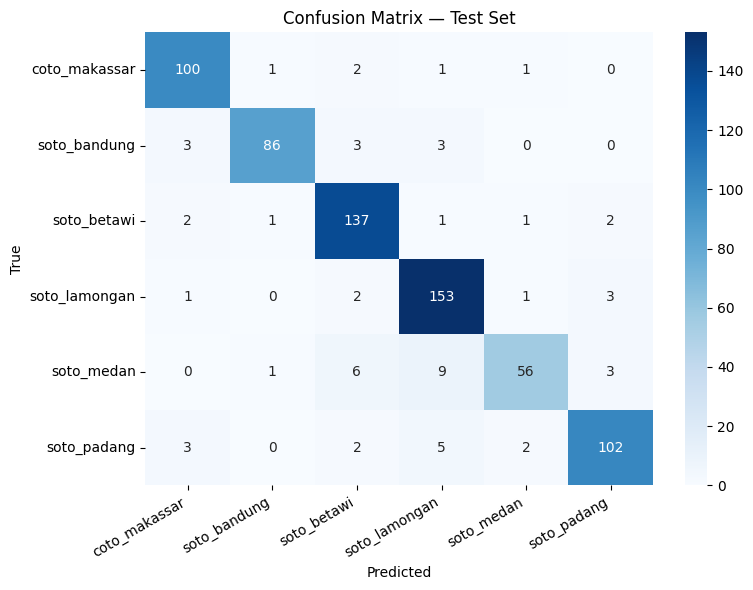

In [11]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Dokumentasi/confusion_matrix(Deit_Base).png", dpi=120)
plt.show()

## 12. Grad-CAM Visualization

In [12]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Reshape transform khusus untuk Vision Transformer (DeiT)
def reshape_transform(tensor, height=14, width=14):
    # Buang CLS token (index 0), ambil patch tokens saja
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # (B, H, W, C) → (B, C, H, W)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Target layer — norm1 di block terakhir DeiT
target_layers = [model.blocks[-1].norm1]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers,
                      reshape_transform=reshape_transform)

def denorm(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = (img * std) + mean
    return np.clip(img, 0, 1)

def get_attribution(img_path, actual_class_str=None):
    from PIL import Image

    pil_img = Image.open(img_path).convert('RGB')
    img_t   = eval_tf(pil_img)
    input_t = img_t.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_t)
        pred_prob, pred_class = torch.max(logits.softmax(1), 1)
        pred_class = pred_class.item()
        pred_prob  = pred_prob.item()

    pred_class_str = full_dataset.classes[pred_class]
    actual_str = f"Actual: {actual_class_str}" if actual_class_str else ""

    rgb_img = denorm(img_t).astype(np.float32)
    grayscale_cam = cam(input_tensor=input_t,
                        targets=[ClassifierOutputTarget(pred_class)])[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{actual_str}\nPredicted: {pred_class_str} ({pred_prob*100:.2f}%)",
                 fontsize=12, fontweight="bold")

    axes[0].imshow(rgb_img)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap='hot')
    axes[1].set_title("Heatmap", fontsize=11)
    axes[1].axis("off")

    axes[2].imshow(cam_image)
    axes[2].set_title("Class Activation Map", fontsize=11)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return pred_class_str, pred_prob

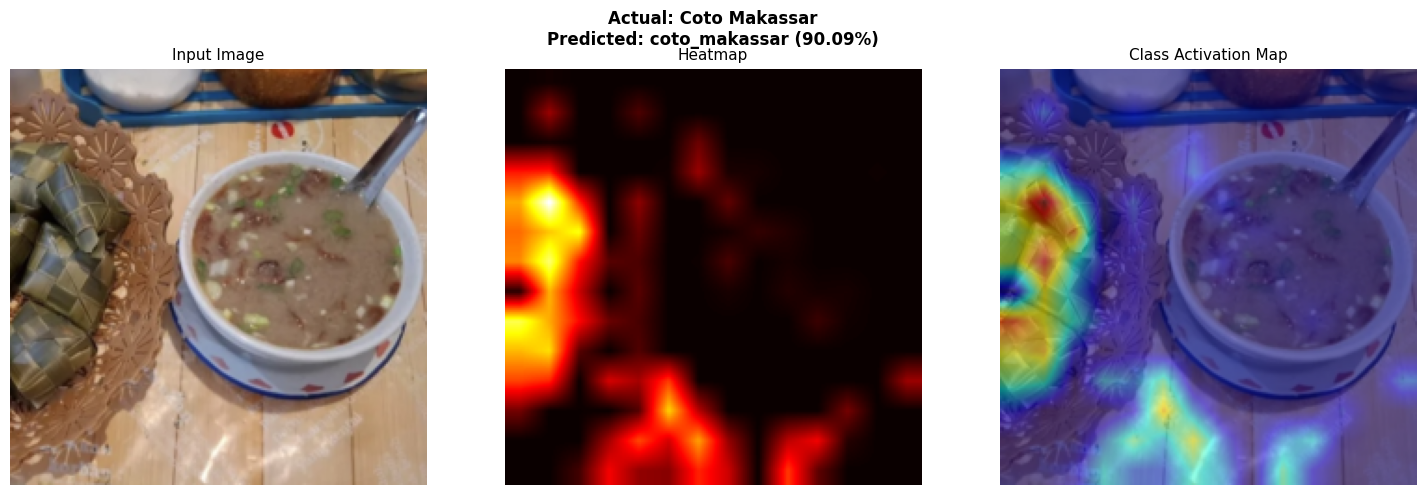

In [13]:
pred = get_attribution('dataset-soto-v2/test/coto_makassar/makassar-0699.jpg', actual_class_str='Coto Makassar')

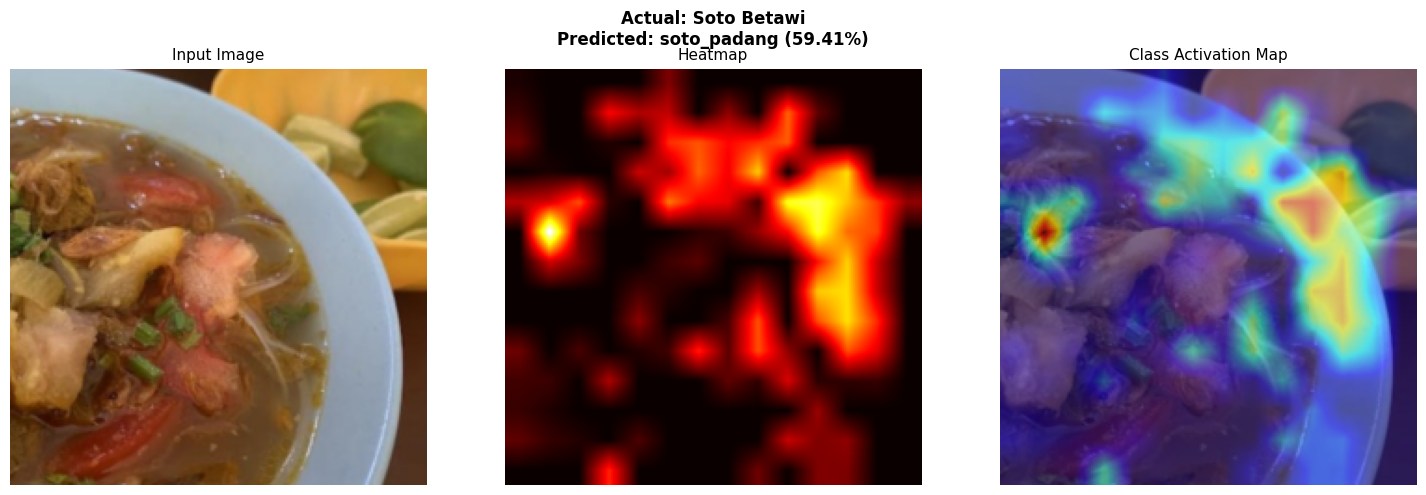

In [14]:
pred = get_attribution('dataset-soto-v2/test/soto_betawi/betawi-0831.jpg', actual_class_str='Soto Betawi')